In [1]:
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist, normhist2d
auto_plot_style()

from utils import draw_el

# pCOLINA 

In [2]:
path = Path("/home/gonzalo/data/COLINA/mc/pcolina/")

dsipms15 = pd.read_hdf(path / "dsipms_15mm_reco_summary.h5")
dsipms2  = pd.read_hdf(path / "dsipms_2mm_reco_summary.h5")

wires10 = pd.read_hdf(path / "pitch_2mm_diam_10um_reco_summary.h5")
wires50 = pd.read_hdf(path / "pitch_2mm_diam_50um_reco_summary.h5")
wires2  = pd.read_hdf(path / "pitch_2mm_diam_2um_reco_summary.h5")

rmax   = 16.1
rbins  = np.linspace(    0, rmax, 81)
xybins = np.linspace(-rmax, rmax, 81)
drbins = np.linspace(    0, rmax, 81)
xyticks = np.arange(-15, 16, 5)
rticks  = np.arange(  0, 16, 2)
extents = (-16, 16, -16, 16)

### Distance shield-sipms

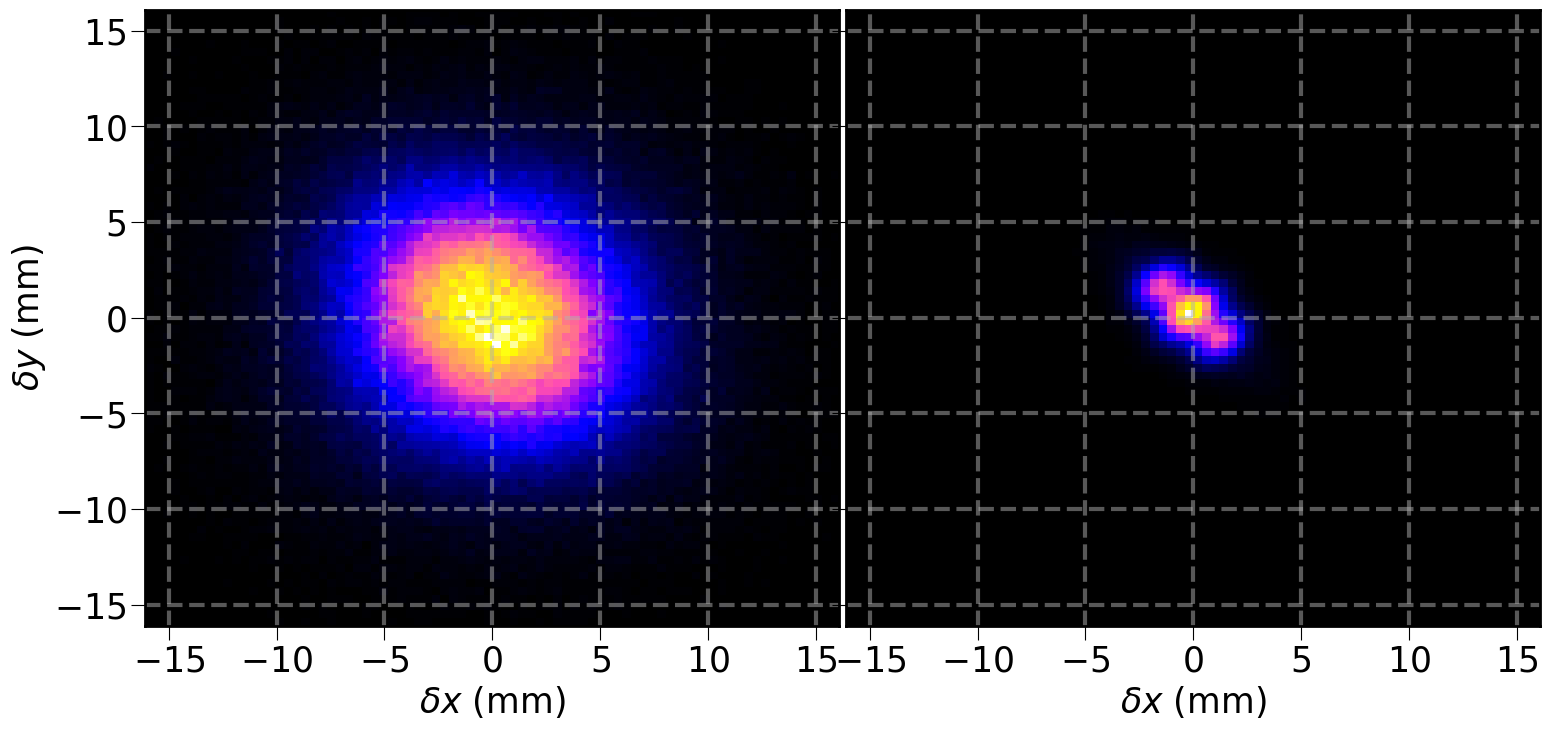

In [4]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = dsipms15, axs[0]
ax.hist2d(df.dx, df.dy, xybins)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_ylabel("$\delta y$ (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

df, ax = dsipms2, axs[1]
ax.hist2d(df.dx, df.dy, xybins)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

plt.subplots_adjust(wspace=.01)

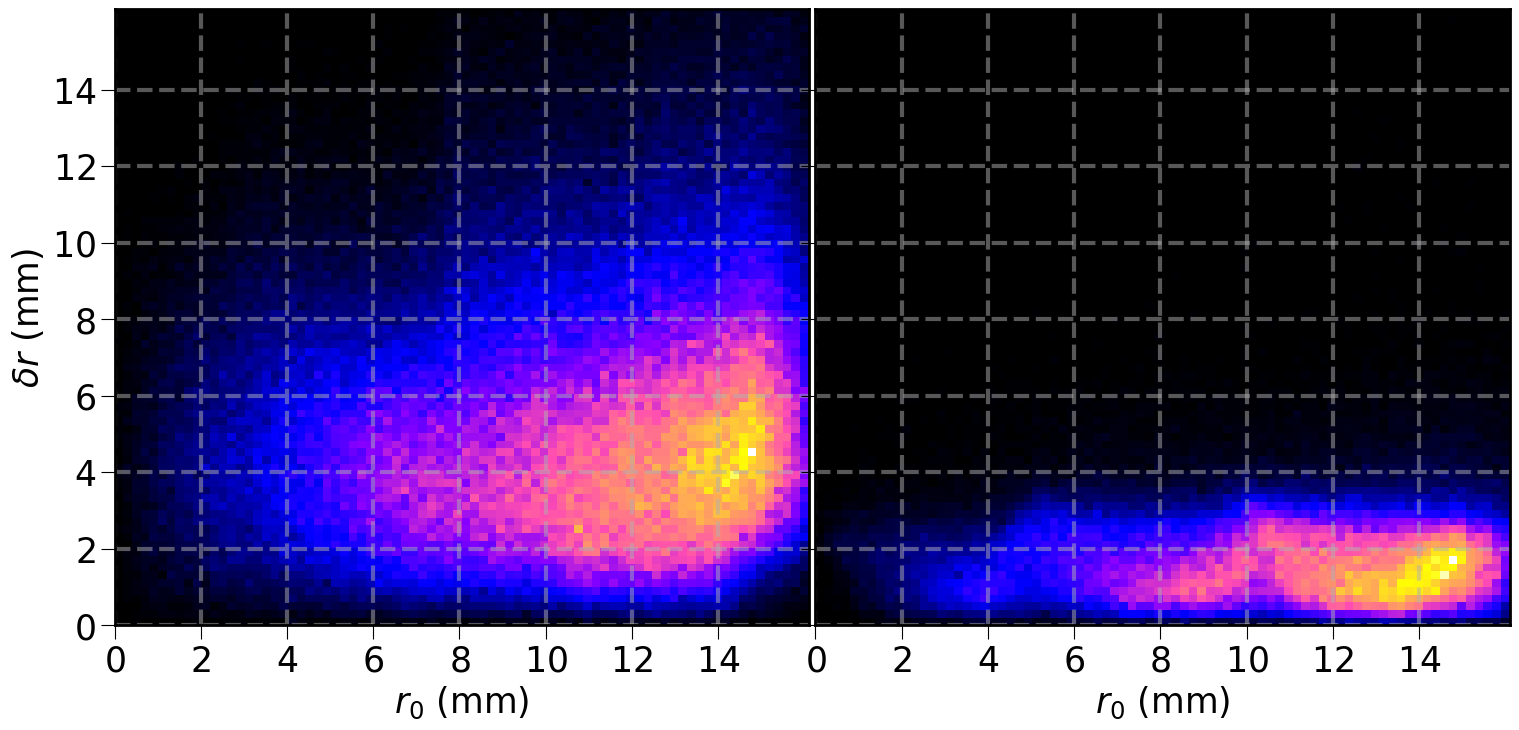

In [5]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = dsipms15, axs[0]
ax.hist2d(df.r0, df.dr, (rbins, drbins))
ax.set_xlabel("$r_0$ (mm)")
ax.set_ylabel("$\delta r$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(rticks)
ax.grid()

df, ax = dsipms2, axs[1]
ax.hist2d(df.r0, df.dr, (rbins, drbins))
ax.set_xlabel("$r_0$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(rticks)
ax.grid()

plt.subplots_adjust(wspace=.01)

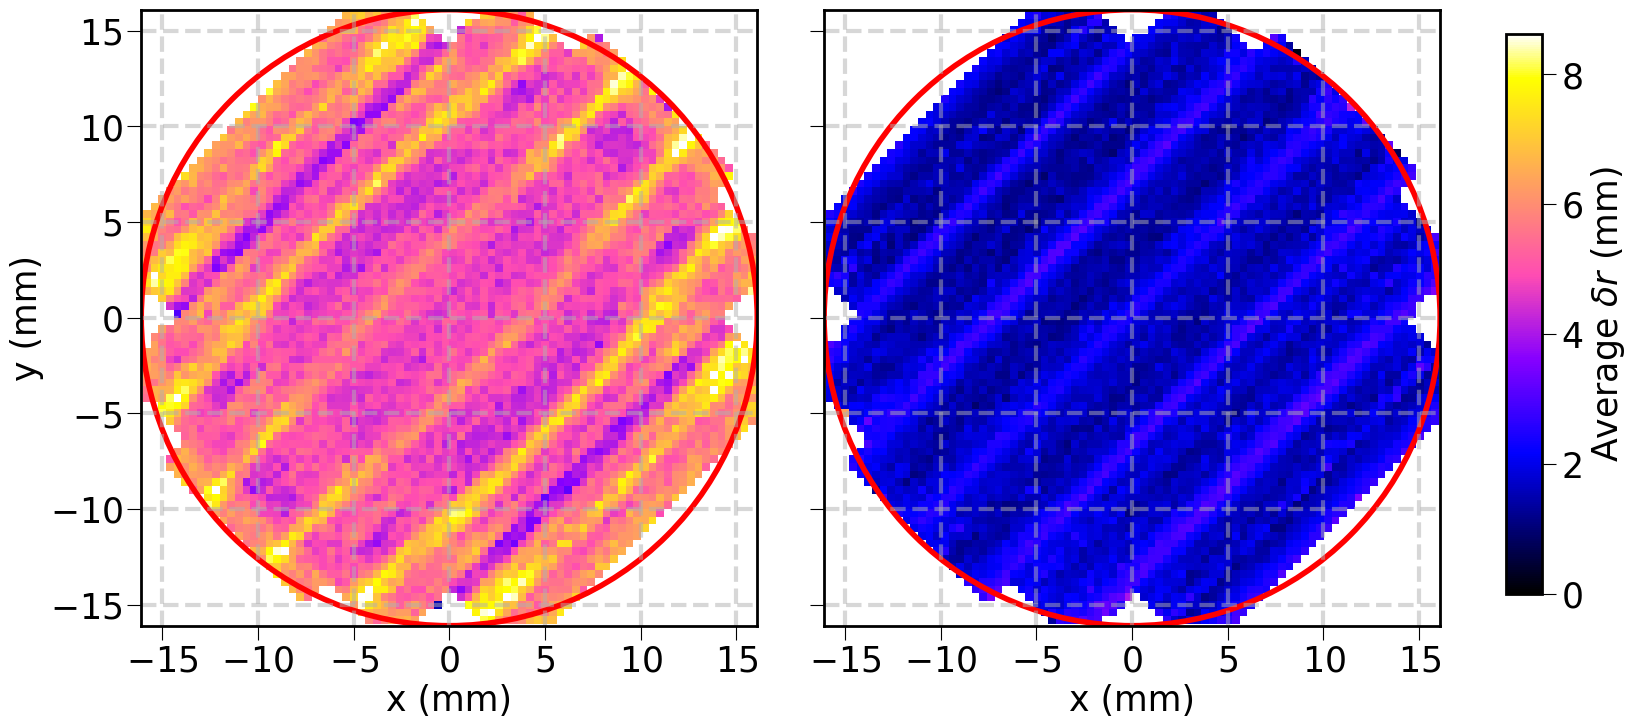

In [6]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = dsipms15, axs[0]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0] / np.clip(evts, 1, None)
vmax = np.percentile(errs[errs>0], 99.5)
errs = np.where(errs>0, errs, np.nan)
im1  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

df, ax = dsipms2, axs[1]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
im2  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cax, location="right").set_label("Average $\delta r$ (mm)")
plt.subplots_adjust(wspace=.01)

### Wire pitch

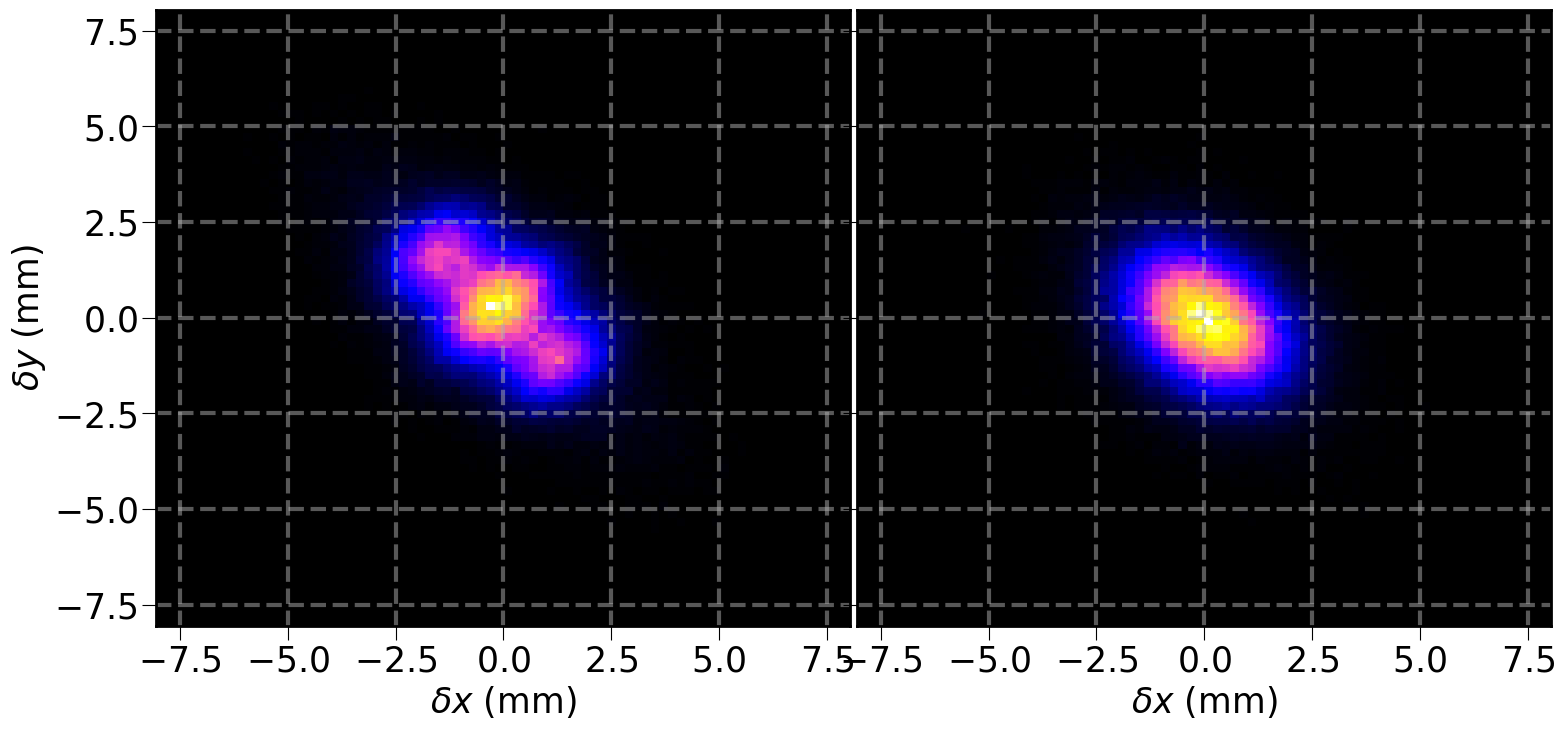

In [15]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = dsipms2, axs[0]
ax.hist2d(df.dx, df.dy, xybins/2)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_ylabel("$\delta y$ (mm)")
ax.set_xticks(xyticks/2)
ax.set_yticks(xyticks/2)
ax.grid()

df, ax = wires10, axs[1]
ax.hist2d(df.dx, df.dy, xybins/2)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_xticks(xyticks/2)
ax.set_yticks(xyticks/2)
ax.grid()

plt.subplots_adjust(wspace=.01)

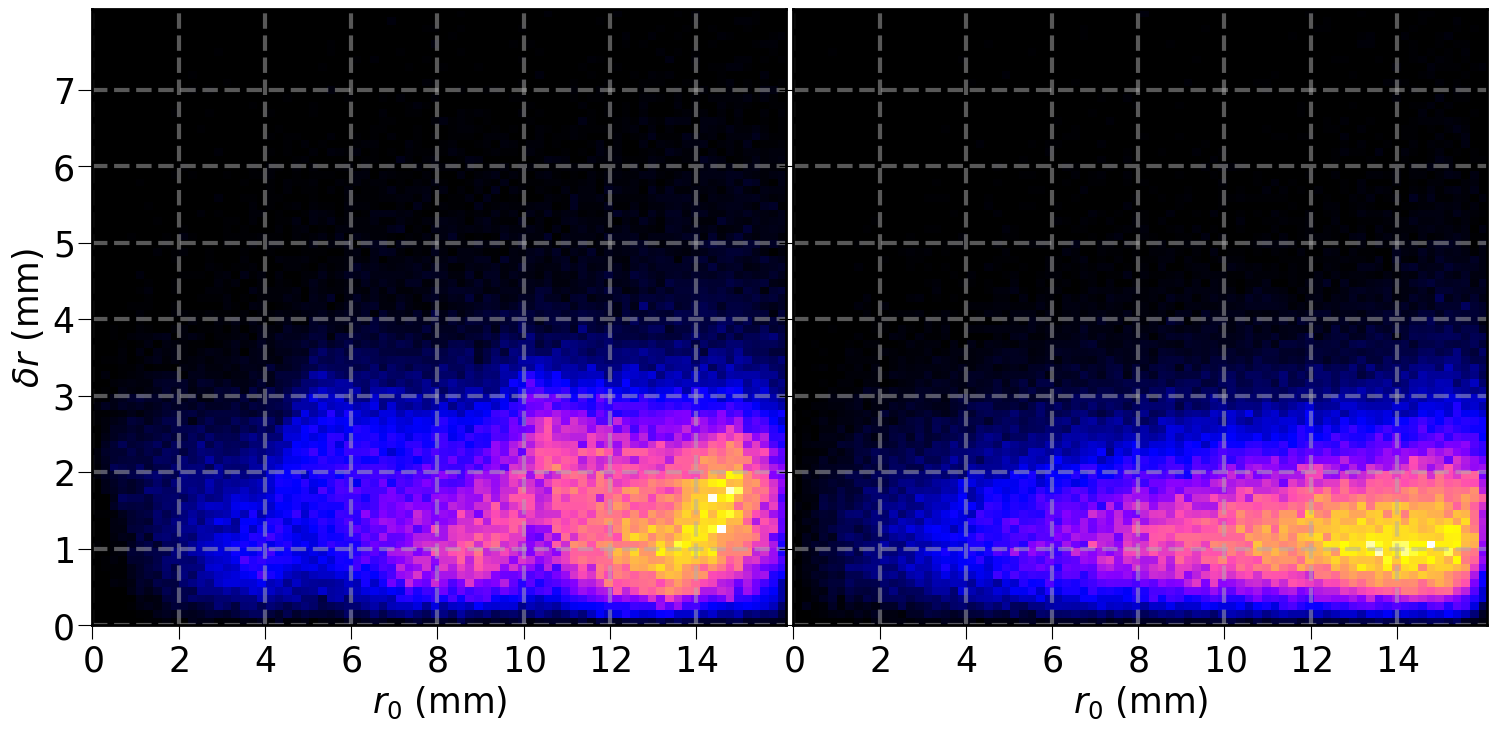

In [10]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = dsipms2, axs[0]
ax.hist2d(df.r0, df.dr, (rbins, drbins/2))
ax.set_xlabel("$r_0$ (mm)")
ax.set_ylabel("$\delta r$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(rticks/2)
ax.grid()

df, ax = wires10, axs[1]
ax.hist2d(df.r0, df.dr, (rbins, drbins/2))
ax.set_xlabel("$r_0$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(rticks/2)
ax.grid()

plt.subplots_adjust(wspace=.01)

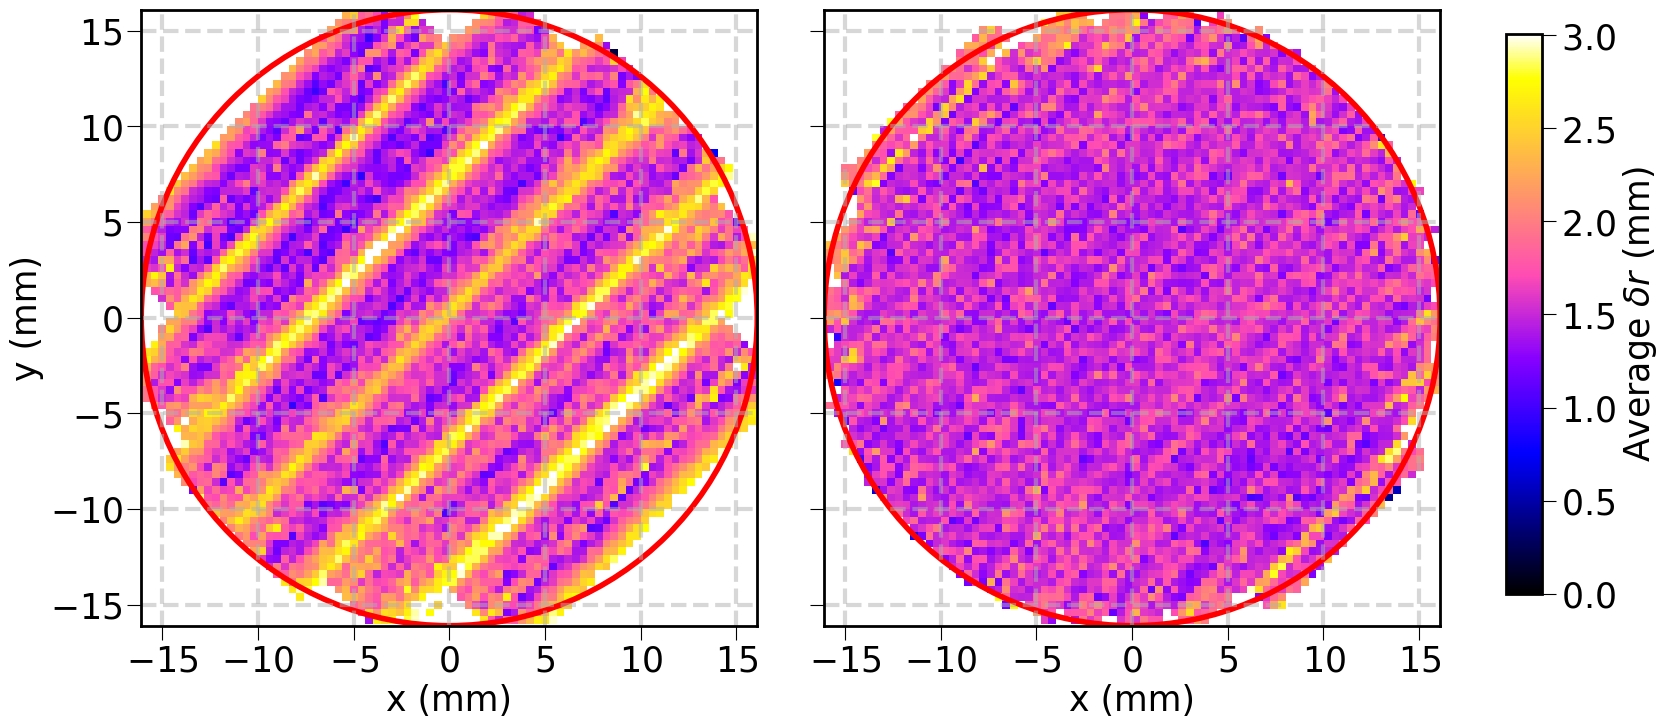

In [14]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = dsipms2, axs[0]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0] / np.clip(evts, 1, None)
vmax = np.percentile(errs[errs>0], 99)
errs = np.where(errs>0, errs, np.nan)
im1  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

df, ax = wires10, axs[1]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
im2  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cax, location="right").set_label("Average $\delta r$ (mm)")
plt.subplots_adjust(wspace=.01)

### Wire diameter

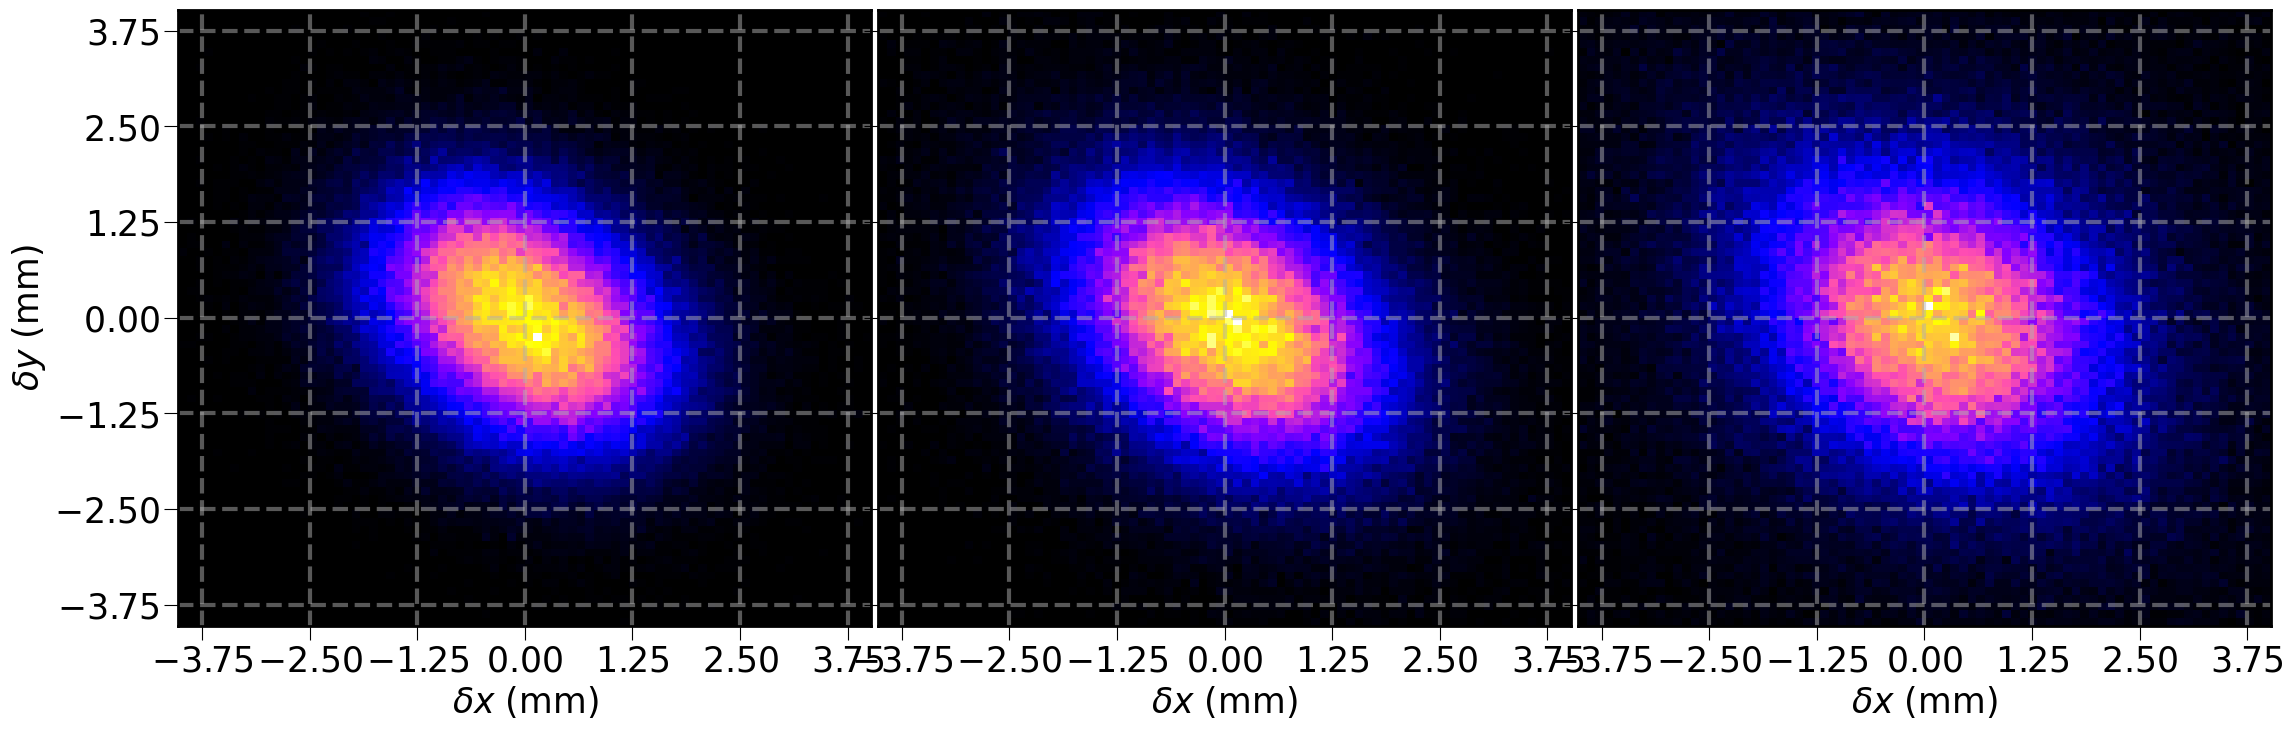

In [21]:
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(27,8))

df, ax = wires2, axs[0]
ax.hist2d(df.dx, df.dy, xybins/4)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_ylabel("$\delta y$ (mm)")
ax.set_xticks(xyticks/4)
ax.set_yticks(xyticks/4)
ax.grid()

df, ax = wires10, axs[1]
ax.hist2d(df.dx, df.dy, xybins/4)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_xticks(xyticks/4)
ax.set_yticks(xyticks/4)
ax.grid()

df, ax = wires50, axs[2]
ax.hist2d(df.dx, df.dy, xybins/4)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_xticks(xyticks/4)
ax.set_yticks(xyticks/4)
ax.grid()

plt.subplots_adjust(wspace=.01)

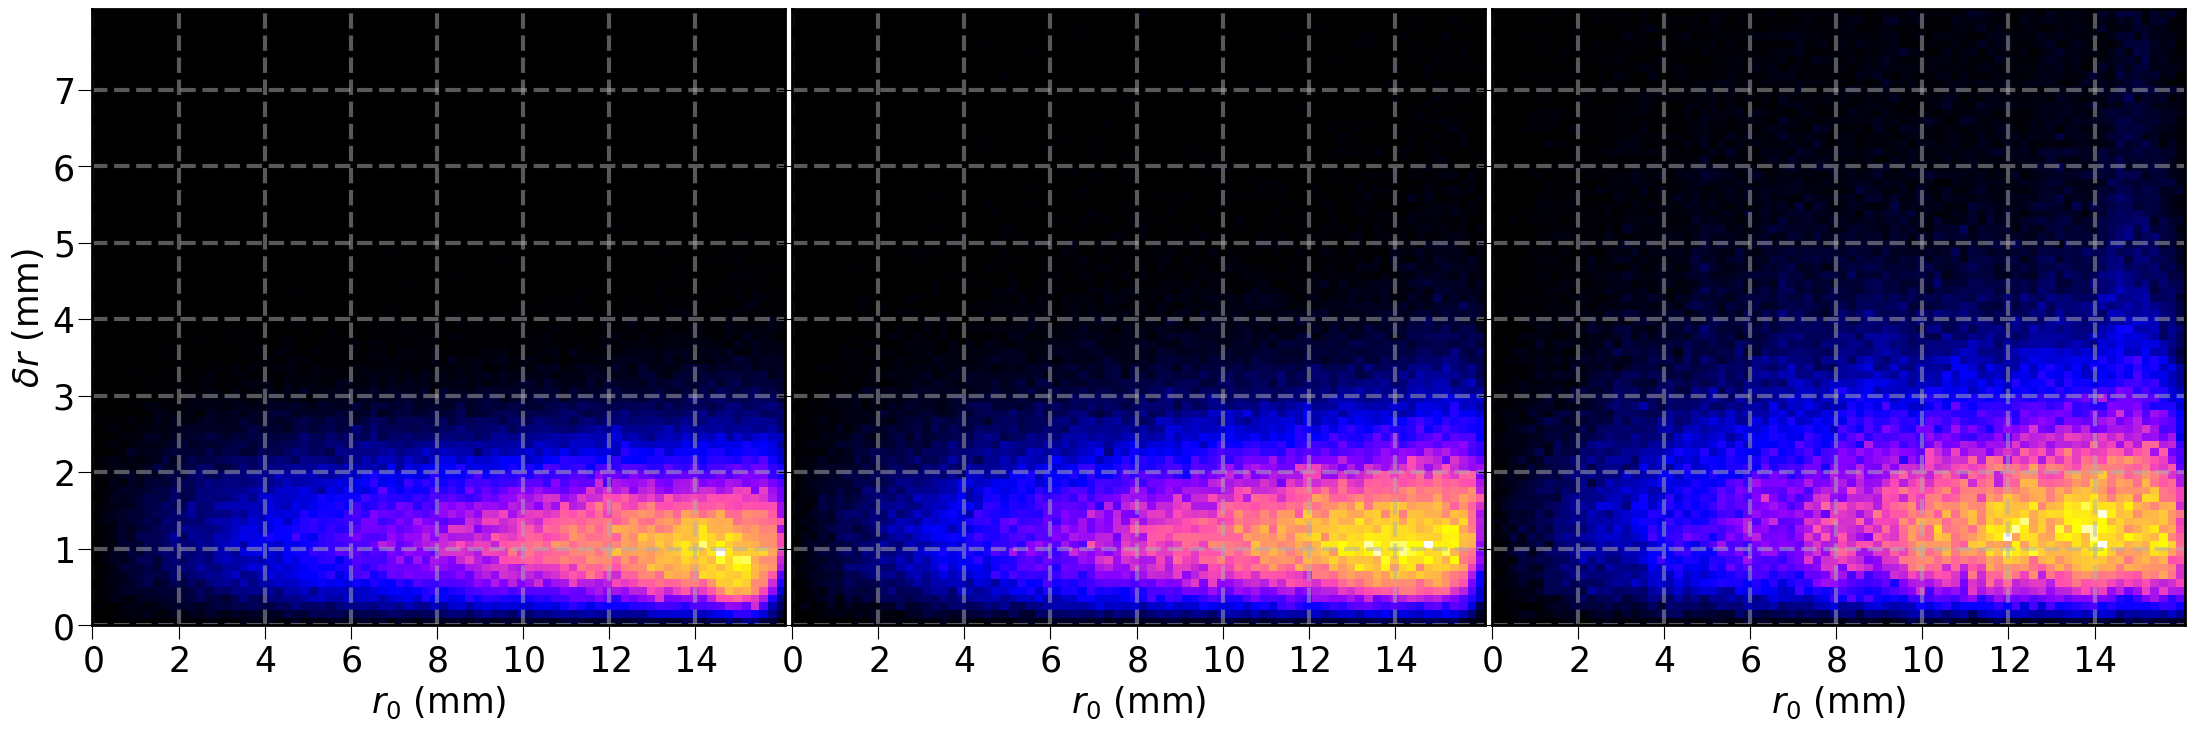

In [24]:
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(27,8))

df, ax = wires2, axs[0]
ax.hist2d(df.r0, df.dr, (rbins, drbins/2))
ax.set_xlabel("$r_0$ (mm)")
ax.set_ylabel("$\delta r$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(rticks/2)
ax.grid()

df, ax = wires10, axs[1]
ax.hist2d(df.r0, df.dr, (rbins, drbins/2))
ax.set_xlabel("$r_0$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(rticks/2)
ax.grid()


df, ax = wires50, axs[2]
ax.hist2d(df.r0, df.dr, (rbins, drbins/2))
ax.set_xlabel("$r_0$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(rticks/2)
ax.grid()

plt.subplots_adjust(wspace=.01)

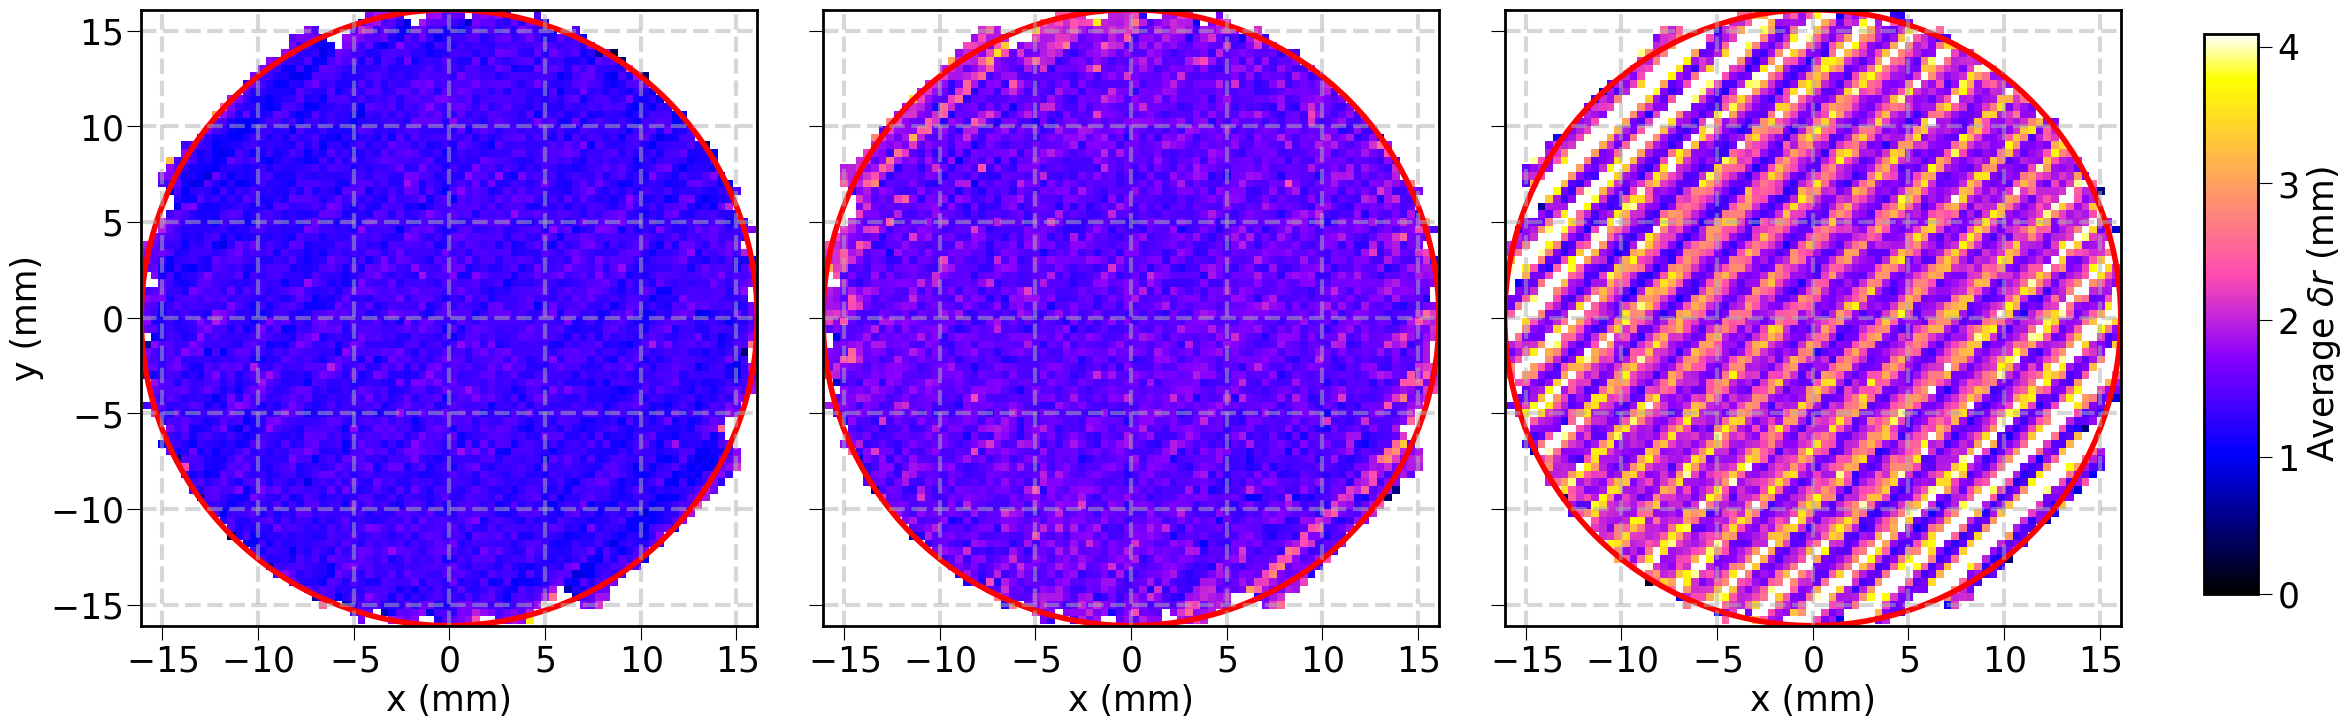

In [27]:
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(27,8))

df, ax = wires2, axs[0]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0] / np.clip(evts, 1, None)
vmax = np.percentile(errs[errs>0], 99.99)
errs = np.where(errs>0, errs, np.nan)
im1  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

df, ax = wires10, axs[1]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
im2  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

df, ax = wires50, axs[2]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
im2  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cax, location="right").set_label("Average $\delta r$ (mm)")
plt.subplots_adjust(wspace=.01)

# COLINA

In [68]:
path = Path("/home/gonzalo/data/COLINA/mc/colina/")

dsipms2   = pd.read_hdf(path / "dsipms_2mm_reco_summary.h5")
dsipms2g  = pd.read_hdf(path / "dsipms_2mm_ganging_reco_summary.h5")

wires2  = pd.read_hdf(path / "pitch_2mm_diam_2um_reco_summary.h5")
wires2g = pd.read_hdf(path / "pitch_2mm_diam_2um_ganging_reco_summary.h5")

rmax   = 32.1
rbins  = np.linspace(    0, rmax, 81)
xybins = np.linspace(-rmax, rmax, 81)
dxybins = np.linspace(-6, 6, 81)
drbins = np.linspace(    0, 10, 81)
xyticks = np.arange(-30, 31, 10)
dxyticks = np.arange(-5, 6, 1)
rticks  = np.arange(  0, 31, 5)
drticks  = np.arange(  0, 11, 2)
extents = (-32, 32, -32, 32)

### Ganging - 10 um wires, 5 mm pitch

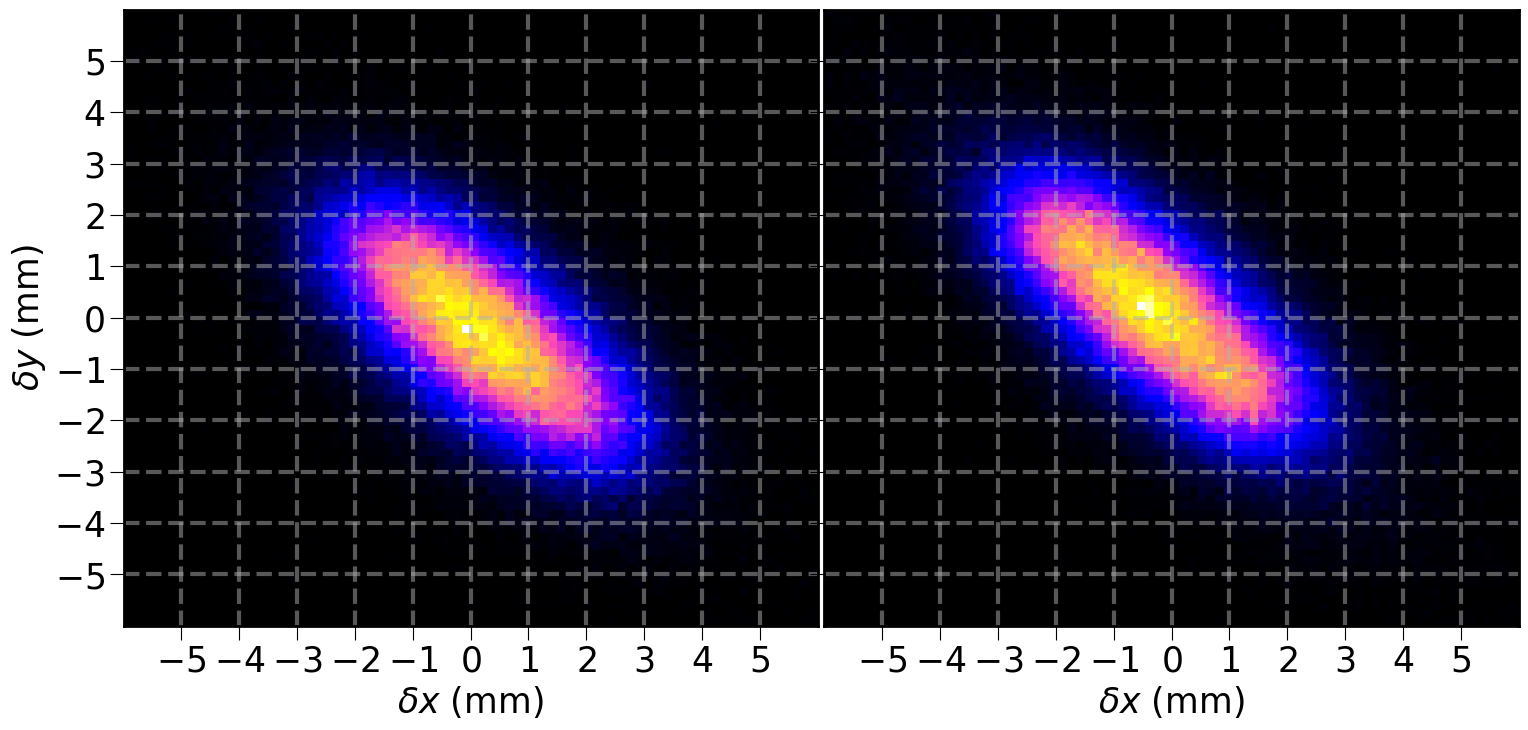

In [63]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = dsipms2, axs[0]
ax.hist2d(df.dx, df.dy, dxybins)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_ylabel("$\delta y$ (mm)")
ax.set_xticks(dxyticks)
ax.set_yticks(dxyticks)
ax.grid()

df, ax = dsipms2g, axs[1]
ax.hist2d(df.dx, df.dy, dxybins)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_xticks(dxyticks)
ax.set_yticks(dxyticks)
ax.grid()

plt.subplots_adjust(wspace=.01)

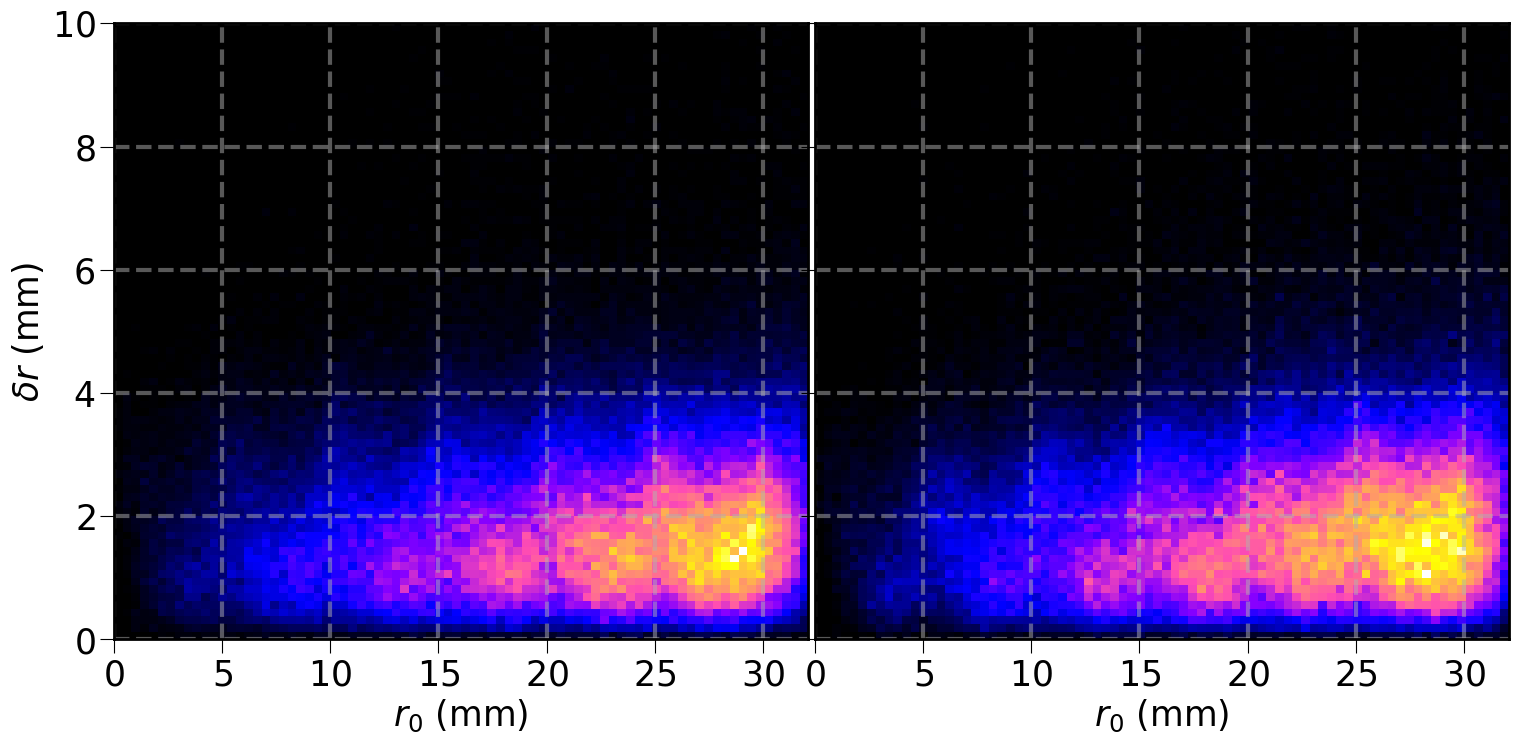

In [64]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = dsipms2, axs[0]
ax.hist2d(df.r0, df.dr, (rbins, drbins))
ax.set_xlabel("$r_0$ (mm)")
ax.set_ylabel("$\delta r$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(drticks)
ax.grid()

df, ax = dsipms2g, axs[1]
ax.hist2d(df.r0, df.dr, (rbins, drbins))
ax.set_xlabel("$r_0$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(drticks)
ax.grid()

plt.subplots_adjust(wspace=.01)

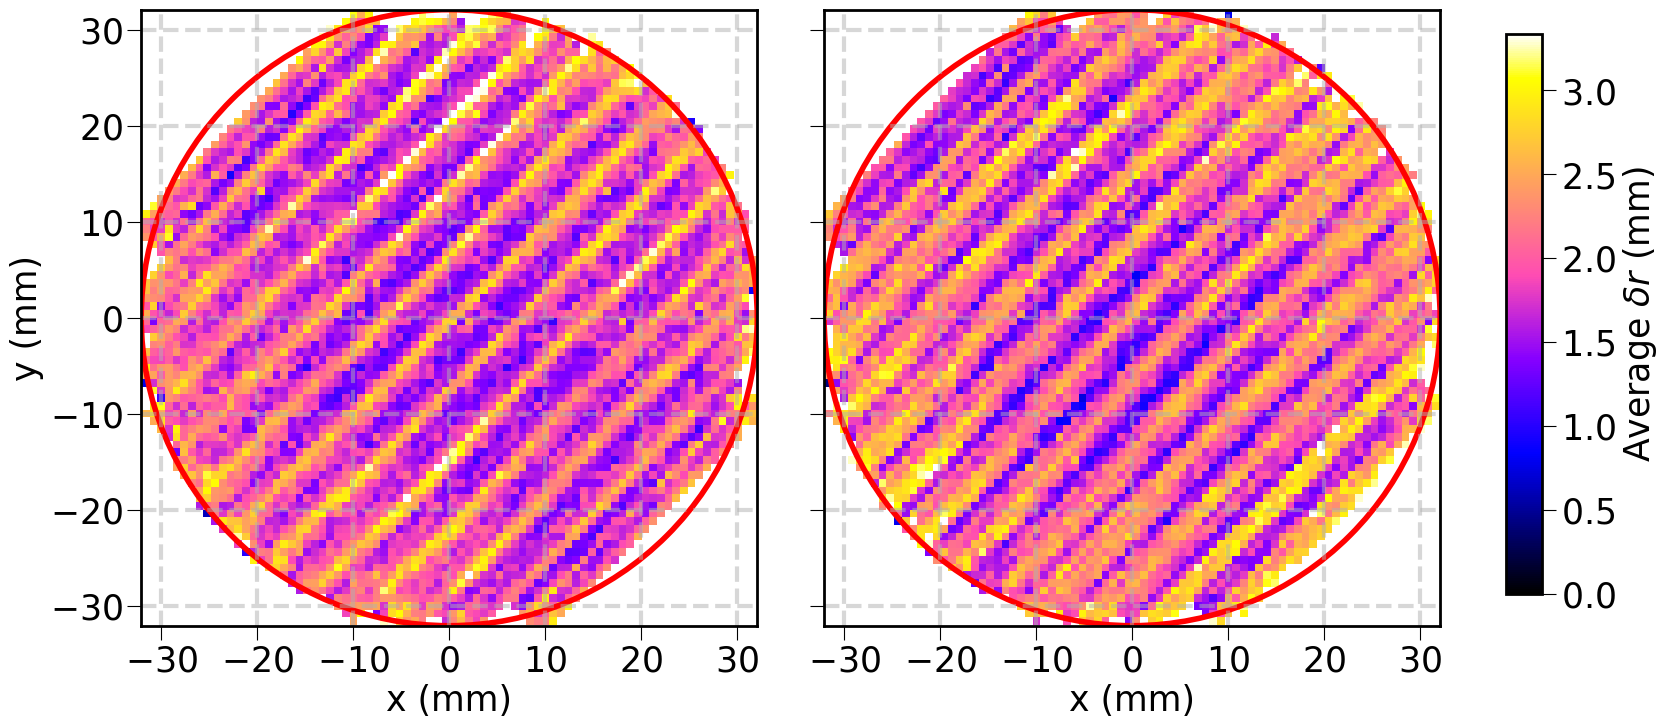

In [67]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = dsipms2, axs[0]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0] / np.clip(evts, 1, None)
vmax = np.percentile(errs[errs>0], 99)
errs = np.where(errs>0, errs, np.nan)
im1  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

df, ax = dsipms2g, axs[1]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
im2  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cax, location="right").set_label("Average $\delta r$ (mm)")
plt.subplots_adjust(wspace=.01)

### Ganging - 2 um wires, 2 mm pitch

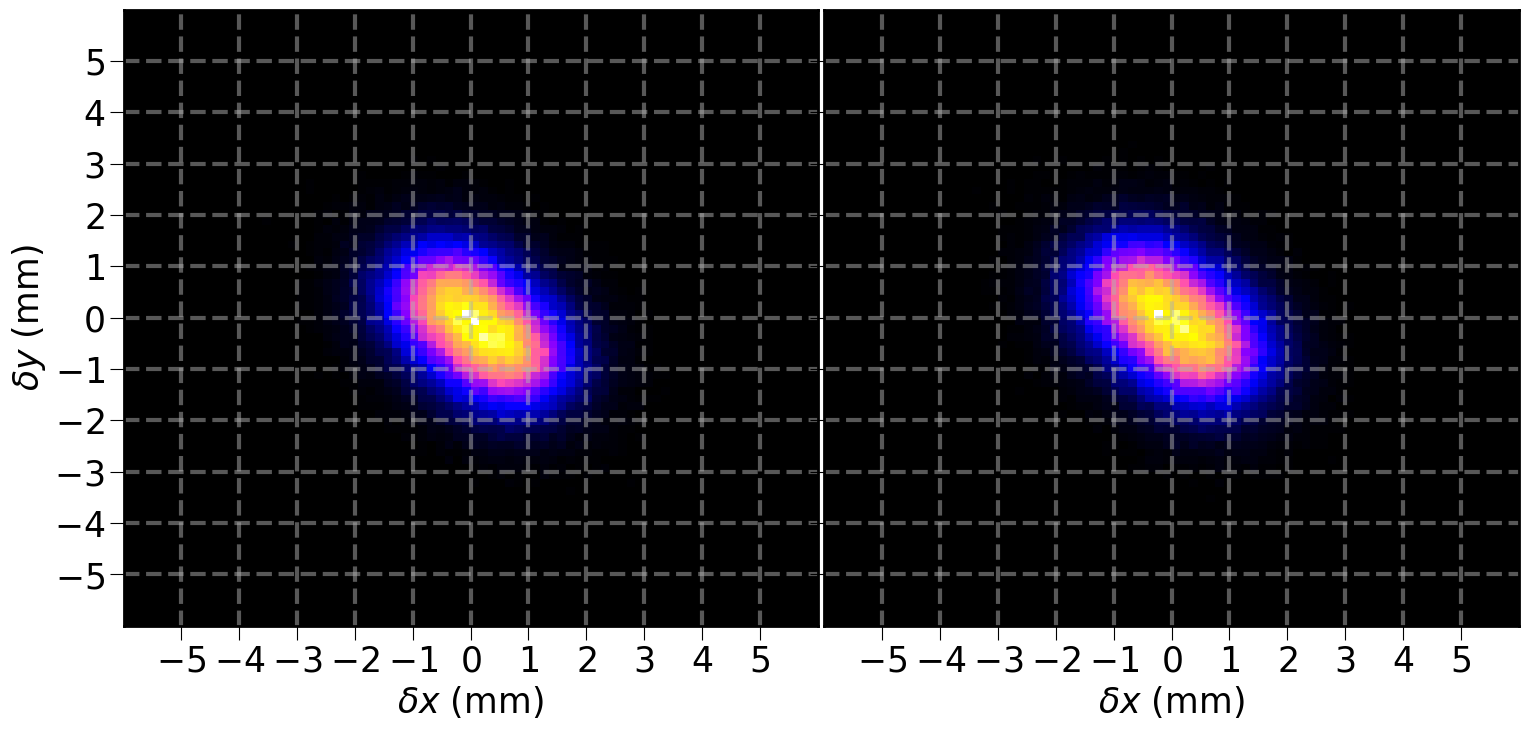

In [69]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = wires2, axs[0]
ax.hist2d(df.dx, df.dy, dxybins)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_ylabel("$\delta y$ (mm)")
ax.set_xticks(dxyticks)
ax.set_yticks(dxyticks)
ax.grid()

df, ax = wires2g, axs[1]
ax.hist2d(df.dx, df.dy, dxybins)
ax.set_xlabel("$\delta x$ (mm)")
ax.set_xticks(dxyticks)
ax.set_yticks(dxyticks)
ax.grid()

plt.subplots_adjust(wspace=.01)

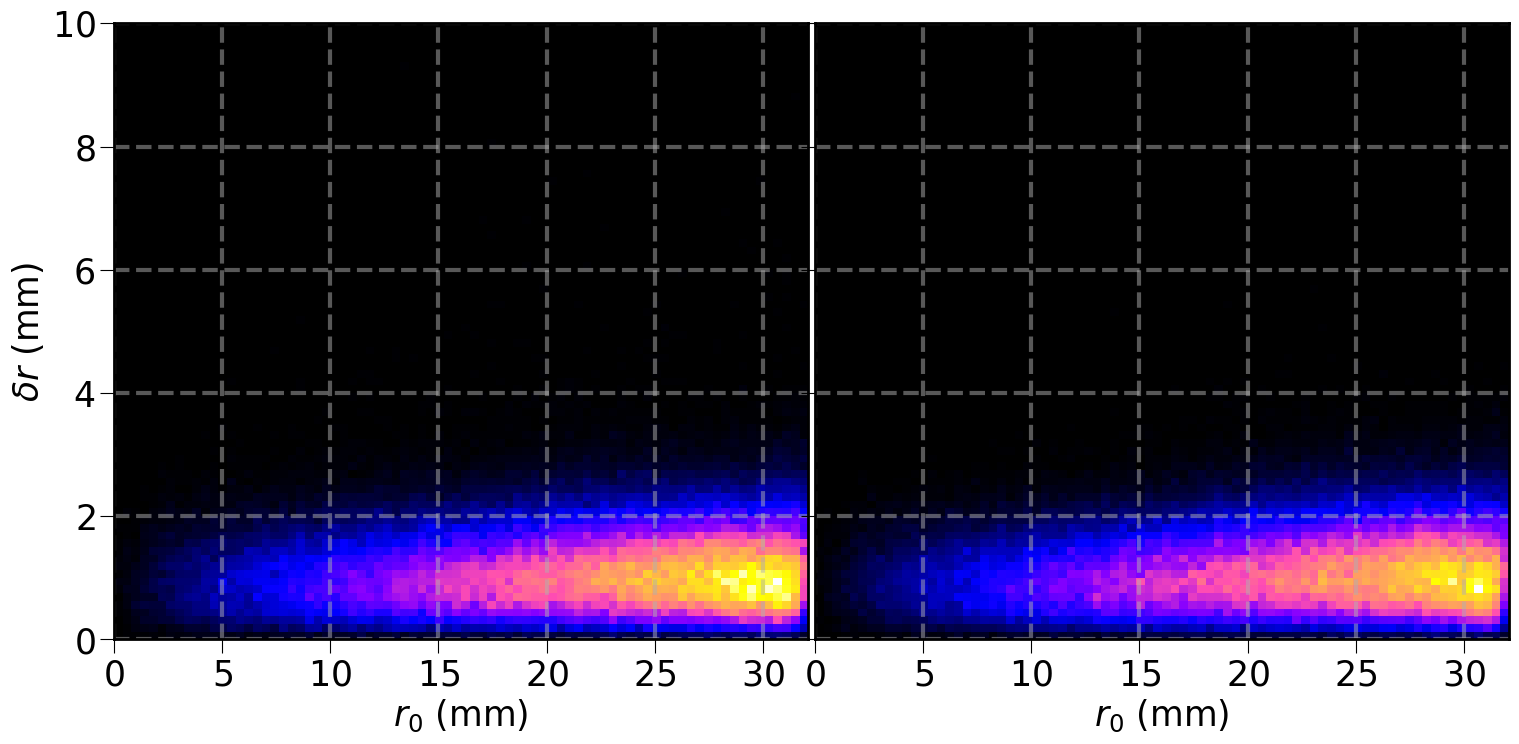

In [70]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = wires2, axs[0]
ax.hist2d(df.r0, df.dr, (rbins, drbins))
ax.set_xlabel("$r_0$ (mm)")
ax.set_ylabel("$\delta r$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(drticks)
ax.grid()

df, ax = wires2g, axs[1]
ax.hist2d(df.r0, df.dr, (rbins, drbins))
ax.set_xlabel("$r_0$ (mm)")
ax.set_xticks(rticks)
ax.set_yticks(drticks)
ax.grid()

plt.subplots_adjust(wspace=.01)

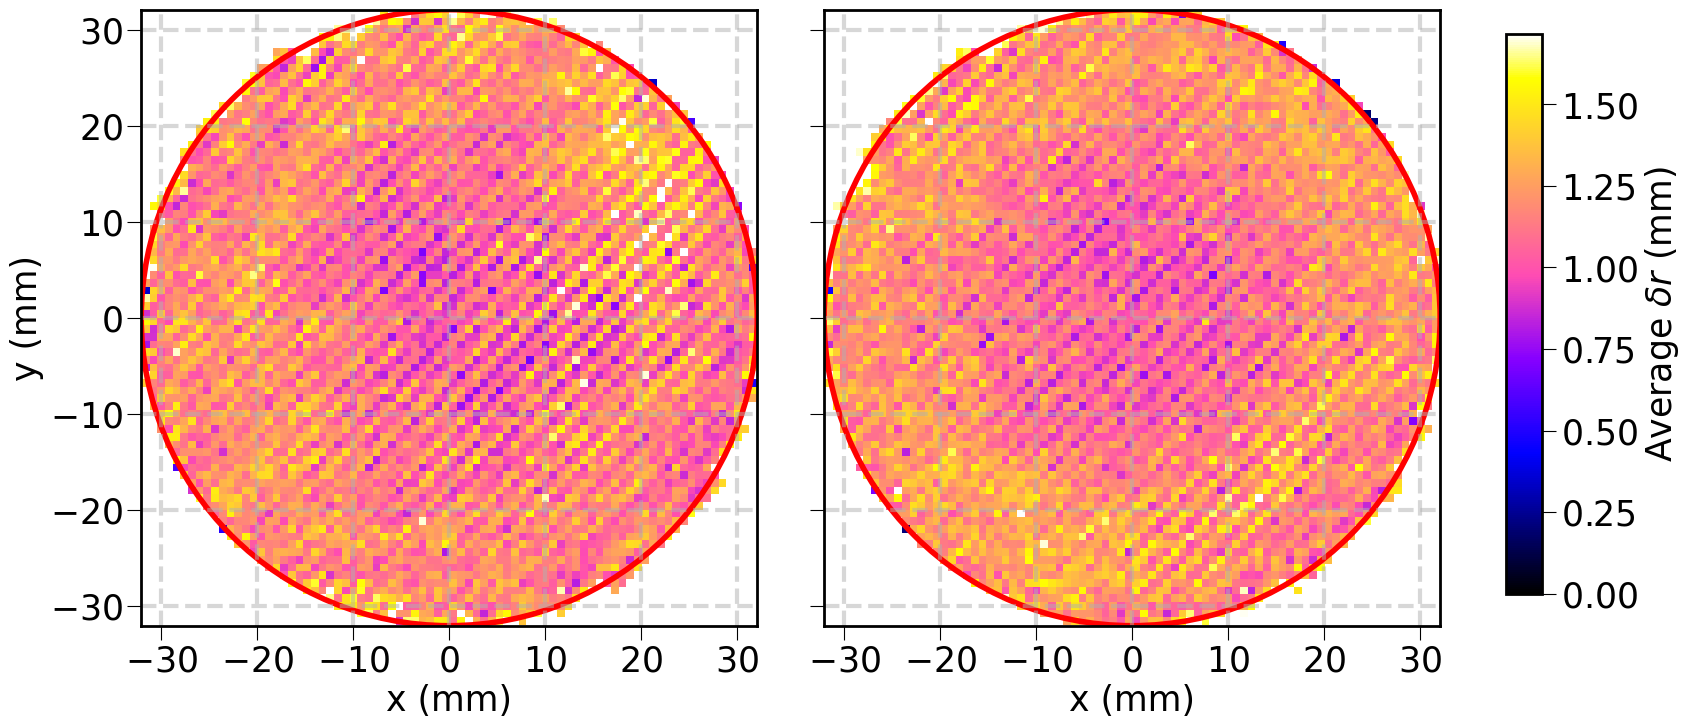

In [71]:
fig, axs = plt.subplots(1, 2, sharey=True, figsize=(18,8))

df, ax = wires2, axs[0]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0] / np.clip(evts, 1, None)
vmax = np.percentile(errs[errs>0], 99)
errs = np.where(errs>0, errs, np.nan)
im1  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

df, ax = wires2g, axs[1]
evts = np.histogram2d(df.x0, df.y0, (xybins, xybins))[0]
errs = np.histogram2d(df.x0, df.y0, (xybins, xybins), weights=df.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
im2  = ax.imshow(errs.T, origin="lower", vmin=0, vmax=vmax, extent=extents)
draw_el(ax, rmax)
ax.set_xlabel("x (mm)")
ax.set_xticks(xyticks)
ax.set_yticks(xyticks)
ax.grid()

fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cax, location="right").set_label("Average $\delta r$ (mm)")
plt.subplots_adjust(wspace=.01)